In [71]:
import pandas as pd
import seaborn as sns

In [2]:
df_1 = pd.read_csv("D:\Iti\Data Exploration\Project\Social-Media-Intelligence-And-Insights\Data\Social Media Engagement Dataset.csv")

In [3]:
df_1.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,12/9/2024 11:26,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,7/28/2024 19:59,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,11/23/2024 14:00,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,9/16/2024 4:35,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,9/5/2024 21:03,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [4]:
df_2 = pd.read_csv("D:\Iti\Data Exploration\Project\Social-Media-Intelligence-And-Insights\Data\social_media_performance.csv")

In [5]:
df_2.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
0,1,LinkedIn,article,Technology,UR,BR,4/25/2025 9:47,#AI #Innovation #TechTrends #Programming #Codi...,0.76,37781,1202,462,185,0.0490,0
1,2,LinkedIn,poll,Health,FR,JP,10/29/2025 9:44,#Fitness #Nutrition #Wellness #Health #MentalH...,0.46,23541,1399,538,215,0.0915,1
2,3,LinkedIn,article,Travel,HI,FR,2/10/2025 14:12,#Travel #Journey #Adventure #Tourism #ExploreM...,-0.01,30714,1663,639,255,0.0833,1
3,4,LinkedIn,image,Sports,DE,DE,4/18/2025 22:41,#Cricket #Workout #Fitness,0.55,31294,1372,528,211,0.0675,0
4,5,LinkedIn,poll,Business,DE,US,4/28/2025 10:17,#Entrepreneur #Leadership #StartupLife,0.70,43129,2234,859,343,0.0797,0


In [6]:
df_1.columns,df_2.columns



(Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
        'location', 'language', 'text_content', 'hashtags', 'mentions',
        'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
        'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
        'comments_count', 'impressions', 'engagement_rate', 'brand_name',
        'product_name', 'campaign_name', 'campaign_phase',
        'user_past_sentiment_avg', 'user_engagement_growth',
        'buzz_change_rate'],
       dtype='str'),
 Index(['post_id', 'platform', 'content_type', 'topic', 'language', 'region',
        'post_datetime', 'hashtags', 'sentiment_score', 'views', 'likes',
        'comments', 'shares', 'engagement_rate', 'is_viral'],
       dtype='str'))

## common columns: 
- post_id (different data types) 
- platform
- timestamp, post_datetime
- language
- location (city, country), region (country apprev.)
- hashtags
- sentiment_score
- likes_count, likes
- comments_count, comments
- shares_count, shares
- engagement_rate


P.S:
- post_id for dataset 1 is a string with random characters, while post_id for dataset 2 is an incremental integer starts from 1 
- Dataset 1 has the info posts about products' reviews and campaigns, while dataset 2 has more general posts.
- You can see how this affect the number of likes, comments, and shares counts 

In [10]:
df_1.describe()

,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


In [11]:
df_2.describe()

,post_id,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,0.440221,212142.158100,15236.87470,5860.139600,2343.759700,0.112667,0.545700
std,2886.89568,0.452148,254526.880805,20450.03532,7865.396933,3146.163176,0.064301,0.497932
min,1.00000,-1.000000,116.000000,3.00000,1.000000,0.000000,0.008300,0.000000
25%,2500.75000,0.160000,30936.500000,1623.00000,624.000000,249.000000,0.061900,0.000000
50%,5000.50000,0.560000,78193.000000,5504.00000,2116.500000,846.500000,0.102000,1.000000
75%,7500.25000,0.780000,343206.750000,21467.25000,8256.250000,3302.500000,0.151925,1.000000
max,10000.00000,1.000000,999022.000000,116255.00000,44713.000000,17885.000000,0.300000,1.000000


In [ ]:
df_1['platform'].unique(), df_2['platform'].unique()

(<StringArray>
 ['Instagram', 'Twitter', 'Reddit', 'YouTube', 'Facebook']
 Length: 5, dtype: str,
 <StringArray>
 ['LinkedIn', 'Instagram', 'Medium', 'YouTube']
 Length: 4, dtype: str)

In [19]:
df_1['language'].unique(), df_2['language'].unique()

(<StringArray>
 ['pt', 'ru', 'en', 'hi', 'ja', 'es', 'de', 'fr', 'ar', 'zh']
 Length: 10, dtype: str,
 <StringArray>
 ['UR', 'FR', 'HI', 'DE', 'ES', 'EN', 'JA', 'PT']
 Length: 8, dtype: str)

In [20]:
df_1['location'].unique(), df_2['region'].unique()

(<StringArray>
 [      'Melbourne, Australia',               'Tokyo, Japan',
              'Beijing, China',             'Lagos, Nigeria',
             'Berlin, Germany',         'Seoul, South Korea',
               'Madrid, Spain',          'São Paulo, Brazil',
                'Milan, Italy',               'Houston, USA',
  'Johannesburg, South Africa',        'Mexico City, Mexico',
             'Toronto, Canada',            'Shanghai, China',
            'Los Angeles, USA',               'Lyon, France',
               'Paris, France',             'Manchester, UK',
                  'Dubai, UAE',            'Munich, Germany',
                'Osaka, Japan',              'New York, USA',
            'Barcelona, Spain',              'Mumbai, India',
                'Chicago, USA',          'Vancouver, Canada',
      'Rio de Janeiro, Brazil',                'Rome, Italy',
                'Delhi, India',          'Sydney, Australia',
                  'London, UK',               'Cairo, E

In [32]:
df_1['engagement_rate'].max(), df_2['engagement_rate'].mean()

(np.float64(32.21171), np.float64(0.11266720000000001))

In [47]:
df_2['topic'].unique()

<StringArray>
[   'Technology',        'Health',        'Travel',        'Sports',
      'Business',          'Food',       'Fashion',     'Lifestyle',
     'Education', 'Entertainment']
Length: 10, dtype: str

There is an outlier in the engagemnt_rate in the first dataset with value 32.21171 while the top 75% is at 0.16

In [55]:
df_2[['engagement_rate',"views",'likes','comments', 'shares']]

,engagement_rate,views,likes,comments,shares
0,0.0490,37781,1202,462,185
1,0.0915,23541,1399,538,215
2,0.0833,30714,1663,639,255
3,0.0675,31294,1372,528,211
4,0.0797,43129,2234,859,343
...,...,...,...,...,...
9995,0.1404,430376,39279,15107,6043
9996,0.0344,559223,12513,4812,1925
9997,0.0587,833212,31796,12229,4891
9998,0.1321,182707,15690,6034,2413


In [59]:
df_2_1 = df_2[['platform', 'language', 'region',
        'post_datetime', 'hashtags', 'sentiment_score', 'likes',
        'comments', 'shares', 'engagement_rate','views' ]]

In [63]:
df_2_1.isnull().sum()

platform           0
language           0
region             0
post_datetime      0
hashtags           0
sentiment_score    0
likes              0
comments           0
shares             0
engagement_rate    0
views              0
dtype: int64

In [67]:
df_1_1 = df_1[['platform', 'language', 'location',
        'timestamp', 'hashtags', 'sentiment_score', 'likes_count',
        'comments_count', 'shares_count', 'engagement_rate' ]]

In [70]:
df_1_1.isnull().sum()

platform           0
language           0
location           0
timestamp          0
hashtags           0
sentiment_score    0
likes_count        0
comments_count     0
shares_count       0
engagement_rate    0
dtype: int64

<Axes: xlabel='engagement_rate'>

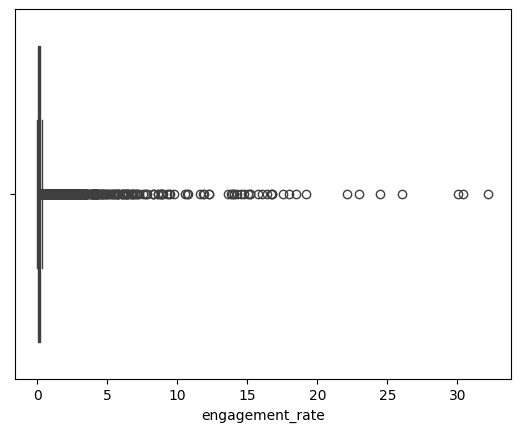

In [74]:
sns.boxplot(x=df_1['engagement_rate'])

In [81]:
df_1[df_1['engagement_rate']>1]['engagement_rate'].count()

np.int64(487)

<Axes: >

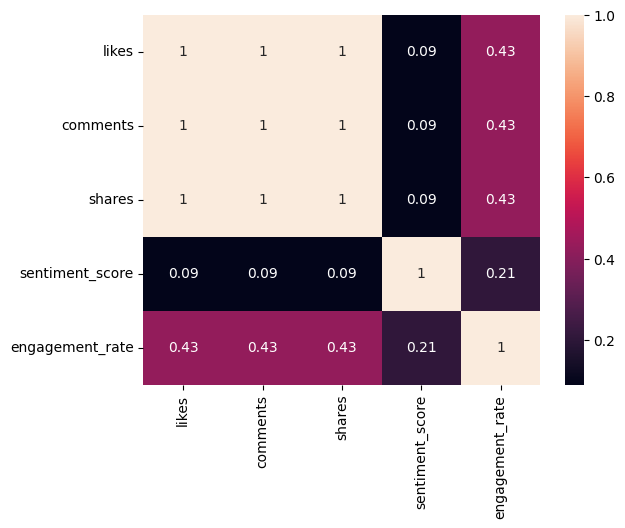

In [82]:
corr = df_2[['likes', 'comments', 'shares', 'sentiment_score', 'engagement_rate']].corr()
sns.heatmap(corr, annot=True)

<Axes: xlabel='sentiment_score', ylabel='engagement_rate'>

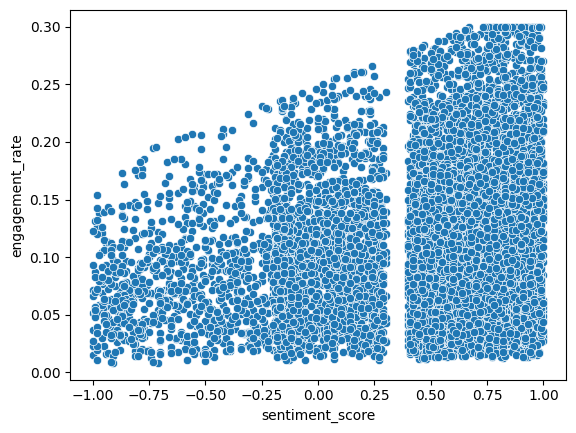

In [84]:
sns.scatterplot(x='sentiment_score', y='engagement_rate', data=df_2)

<Axes: xlabel='platform', ylabel='engagement_rate'>

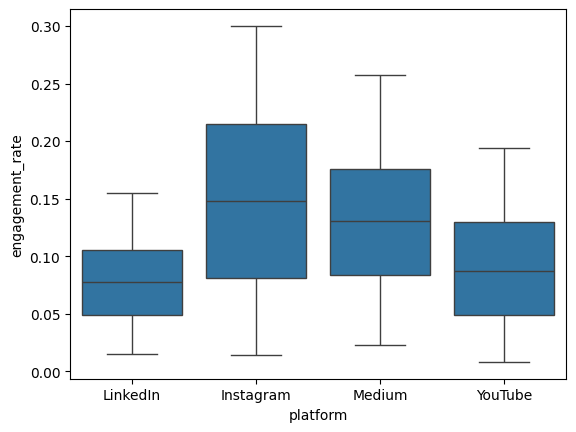

In [87]:
sns.boxplot(x='platform', y='engagement_rate', data=df_2)

<Axes: xlabel='content_type', ylabel='engagement_rate'>

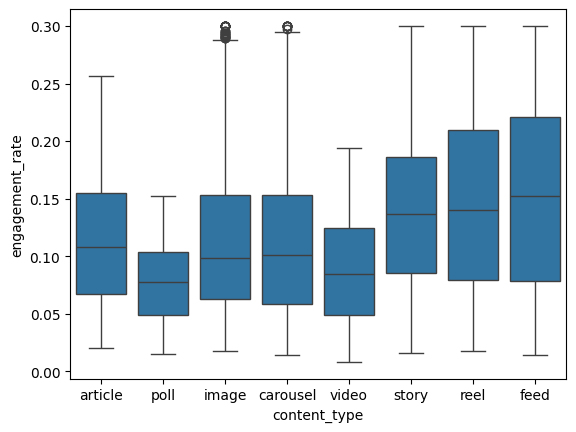

In [89]:
sns.boxplot(x='content_type', y='engagement_rate', data=df_2)

<Axes: xlabel='hour', ylabel='engagement_rate'>

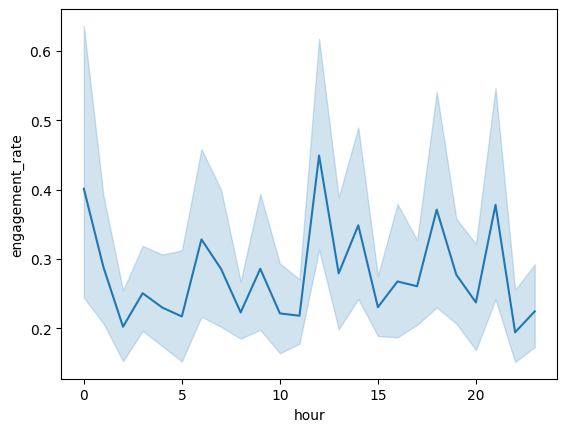

In [93]:
df_1['hour'] = pd.to_datetime(df_1['timestamp']).dt.hour
sns.lineplot(x='hour', y='engagement_rate', data=df_1)